In [1]:
import  pandas as pd
import numpy as np
df1 = pd.read_csv('/content/train.csv')
df2 = pd.read_csv('/content/transactions.csv')
df3 = pd.read_csv('/content/stores.csv')
df4 = pd.read_csv('/content/oil.csv')
df5 = pd.read_csv('/content/holidays_events.csv')
df1.shape

(3000888, 6)

In [2]:
df1 = df1.merge(df2,
                on  = ['date','store_nbr'],
                how='left')
df1 = df1.merge(df3,
                on  = ['store_nbr'],
                how='left')
df1 = df1.merge(df4,
                on  = ['date'],
                how='left')

In [3]:
print("Rows before merge:", len(pd.read_csv("/content/train.csv")))
print("Rows after merge:", len(df1))

Rows before merge: 3000888
Rows after merge: 3000888


In [4]:
df1.head(5)

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,Quito,Pichincha,D,13,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,Quito,Pichincha,D,13,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,Quito,Pichincha,D,13,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,Quito,Pichincha,D,13,NaN


In [5]:
from os.path import join
#National
national=df5[df5['locale']=='National'].copy()
national_summary = (national.groupby('date').agg({'description':','.join,'type':','.join,'transferred':'max'})).reset_index()
national_summary=national_summary.rename(columns={'description':"National_Holiday",'type':'National_Holiday_Type','transferred':'National_transferred'})
#Regional
regional=df5[df5['locale']=='Regional'].copy()
regional_summary= (regional.groupby(['date','locale_name']).agg({'description':','.join,'type':','.join,'transferred':'max'})).reset_index()
regional_summary=regional_summary.rename(columns={'locale_name':'state','description':"Regional_Holiday",'type':'Regional_Holiday_Type','transferred':'Regional_transferred'})
#Local
local = df5[df5['locale']=='Local'].copy()
local_summary= (local.groupby(['date','locale_name']).agg({'description':','.join,'type':','.join,'transferred':'max'})).reset_index()
local_summary=local_summary.rename(columns={'locale_name':'city','description':"Local_Holiday",'type':'Local_Holiday_Type','transferred':'Local_transferred'})

In [6]:
df1 = df1.merge(national_summary,on=['date'],how='left') #Merging National

In [7]:
df1 = df1.merge(regional_summary,on=['date','state'],how='left') #Merging Regional

In [8]:
df1 = df1.merge(local_summary,on=['date','city'],how='left') #Merging Local

In [9]:
df1.shape

(3000888, 21)

In [10]:
df1.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'transactions', 'city', 'state', 'type', 'cluster', 'dcoilwtico',
       'National_Holiday', 'National_Holiday_Type', 'National_transferred',
       'Regional_Holiday', 'Regional_Holiday_Type', 'Regional_transferred',
       'Local_Holiday', 'Local_Holiday_Type', 'Local_transferred'],
      dtype='object')

In [11]:
df1.head(5) #Final Dataset

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,...,dcoilwtico,National_Holiday,National_Holiday_Type,National_transferred,Regional_Holiday,Regional_Holiday_Type,Regional_transferred,Local_Holiday,Local_Holiday_Type,Local_transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df1 = df1.drop(['id','date'],axis=1)
df1.head(5)

,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster,dcoilwtico,National_Holiday,National_Holiday_Type,National_transferred,Regional_Holiday,Regional_Holiday_Type,Regional_transferred,Local_Holiday,Local_Holiday_Type,Local_transferred
0,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BABY CARE,0.0,0,NaN,Quito,Pichincha,D,13,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
2,1,BEAUTY,0.0,0,NaN,Quito,Pichincha,D,13,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
3,1,BEVERAGES,0.0,0,NaN,Quito,Pichincha,D,13,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
4,1,BOOKS,0.0,0,NaN,Quito,Pichincha,D,13,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df1.dtypes

,0
store_nbr,int64
family,object
sales,float64
onpromotion,int64
transactions,float64
city,object
state,object
type,object
cluster,int64
dcoilwtico,float64


             city                           state       sales
0           Quito                       Pichincha  556.577090
1         Cayambe                       Pichincha  509.709179
2          Ambato                      Tungurahua  362.632273
3           Daule                          Guayas  345.282181
4            Loja                            Loja  339.379530
5        Babahoyo                        Los Rios  319.349181
6         Machala                          El Oro  300.392253
7      Esmeraldas                      Esmeraldas  294.963151
8          Cuenca                           Azuay  294.924279
9       Guayaquil                          Guayas  276.594464
10       Libertad                          Guayas  275.722146
11        Quevedo                        Los Rios  255.137503
12       Guaranda                         Bolivar  234.821670
13  Santo Domingo  Santo Domingo de los Tsachilas  214.942315
14         Ibarra                        Imbabura  206.061866
15      

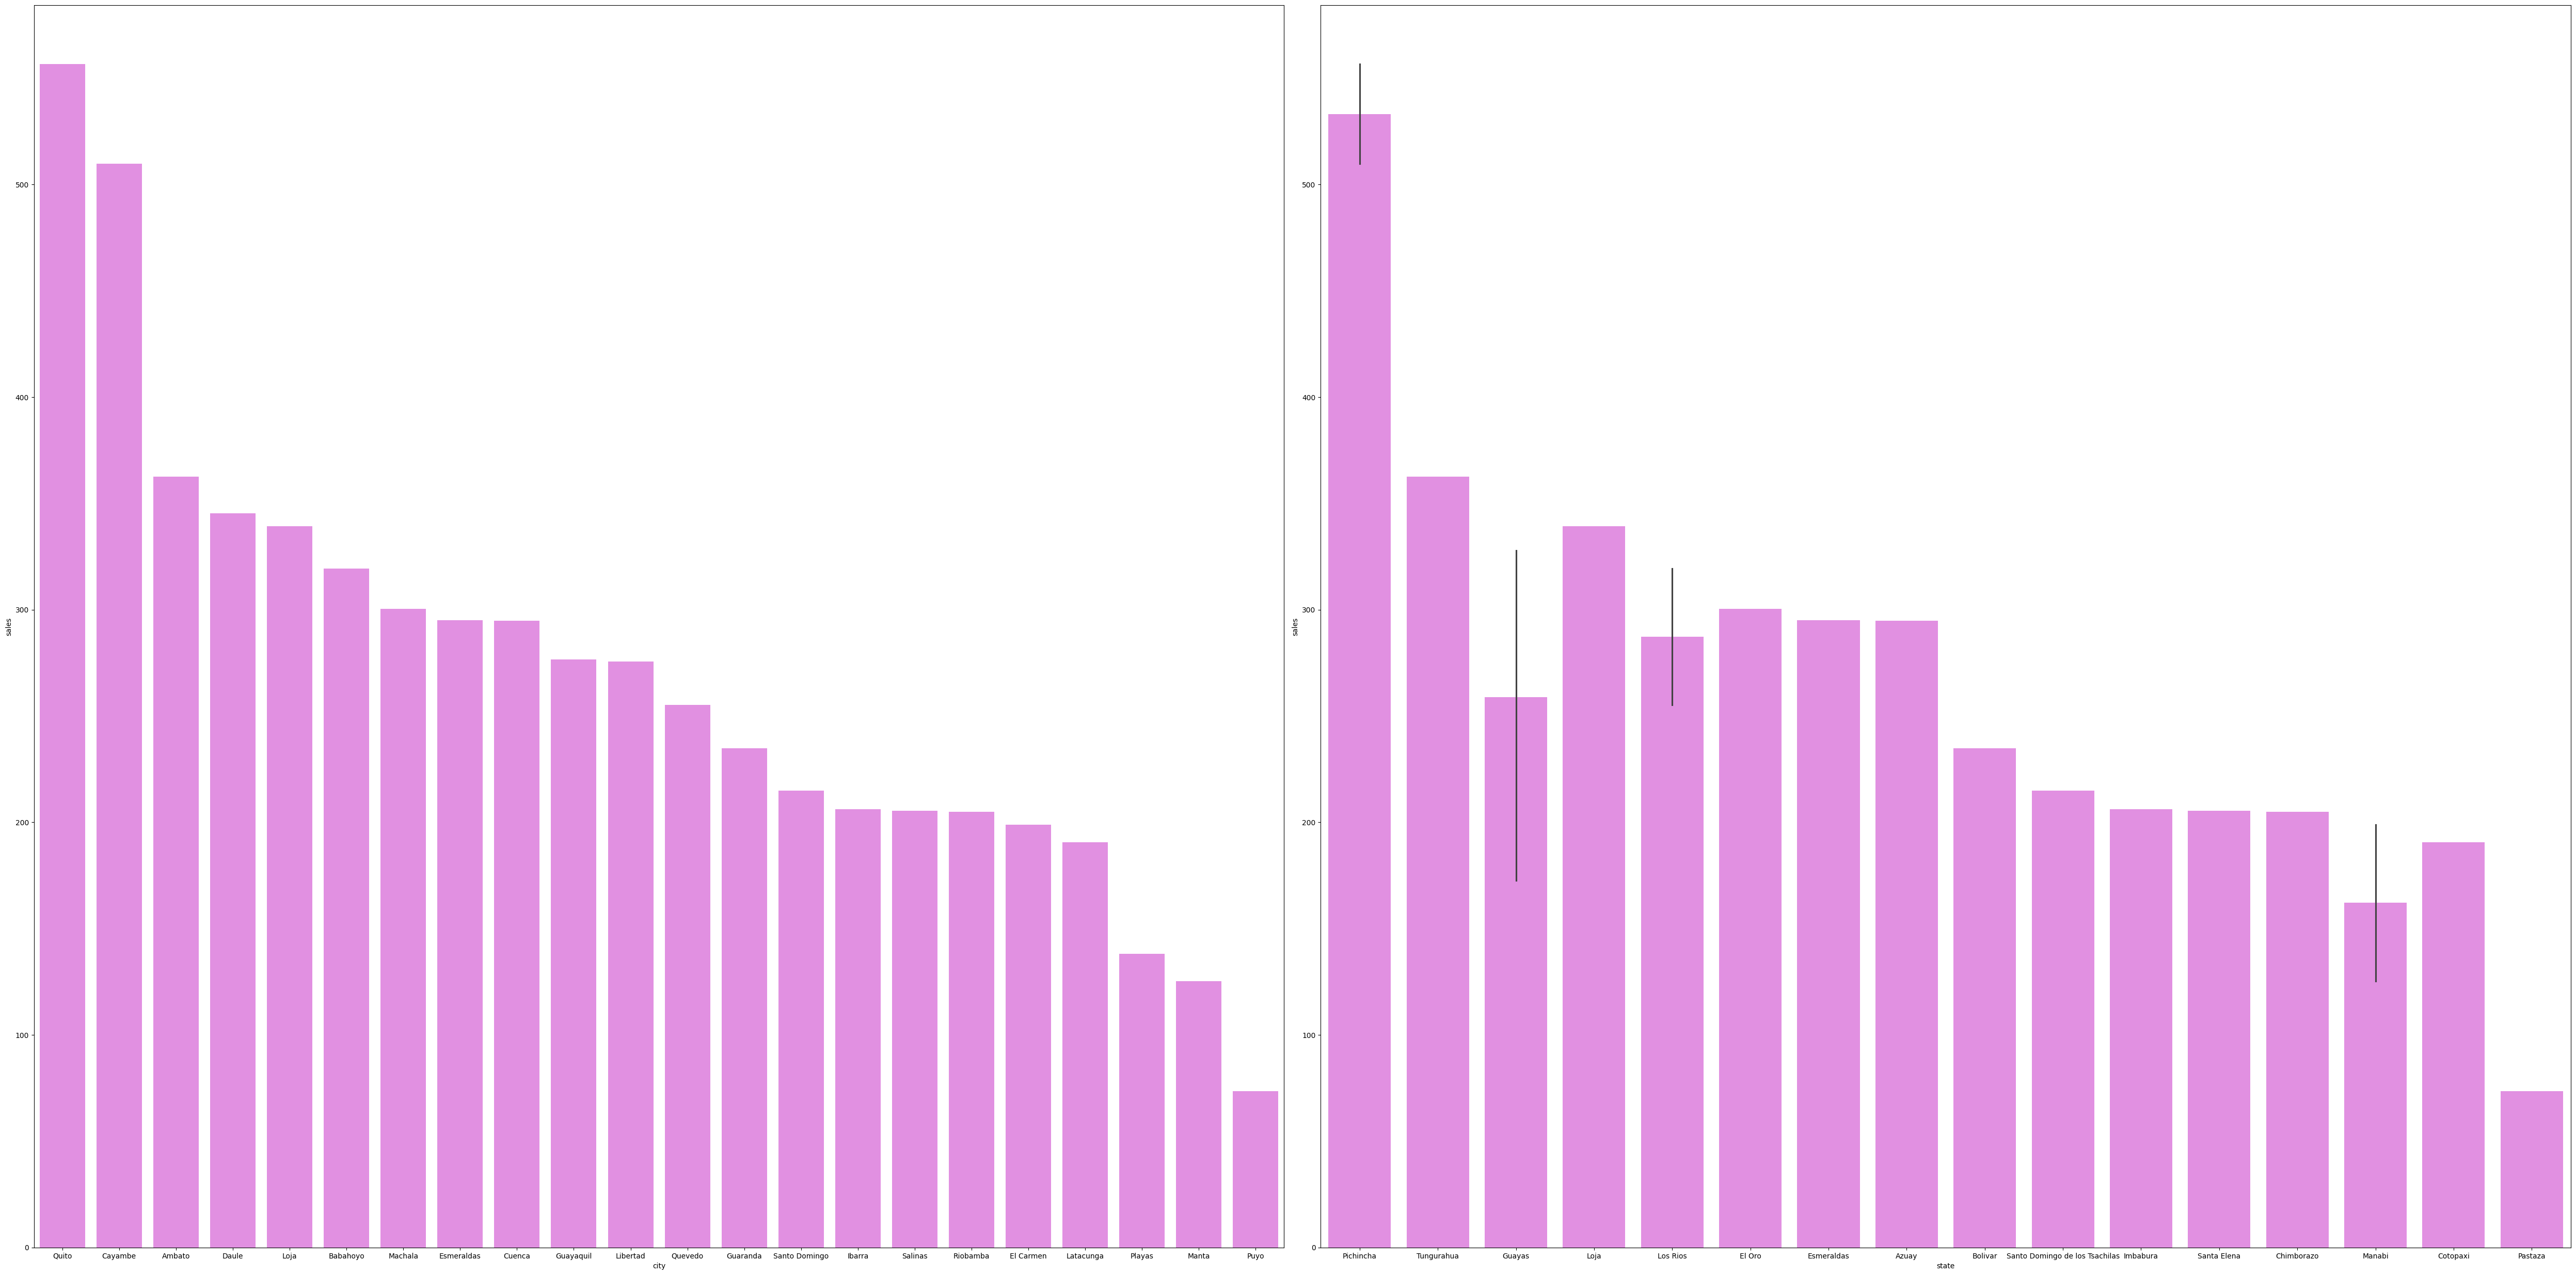

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
df  = df1.copy()
plt.figure(figsize=(50,49))
plt.subplot(2,2,1)
city_sales=df1.groupby(['city','state'])['sales'].mean().sort_values(ascending=False).reset_index()
print(city_sales)
sns.barplot(x='city',y='sales',data=city_sales,color='violet')
plt.subplot(2,2,2)
sns.barplot(x='state',y='sales',data=city_sales,color='violet')
plt.tight_layout()
plt.show()
#avg sales per each city and state

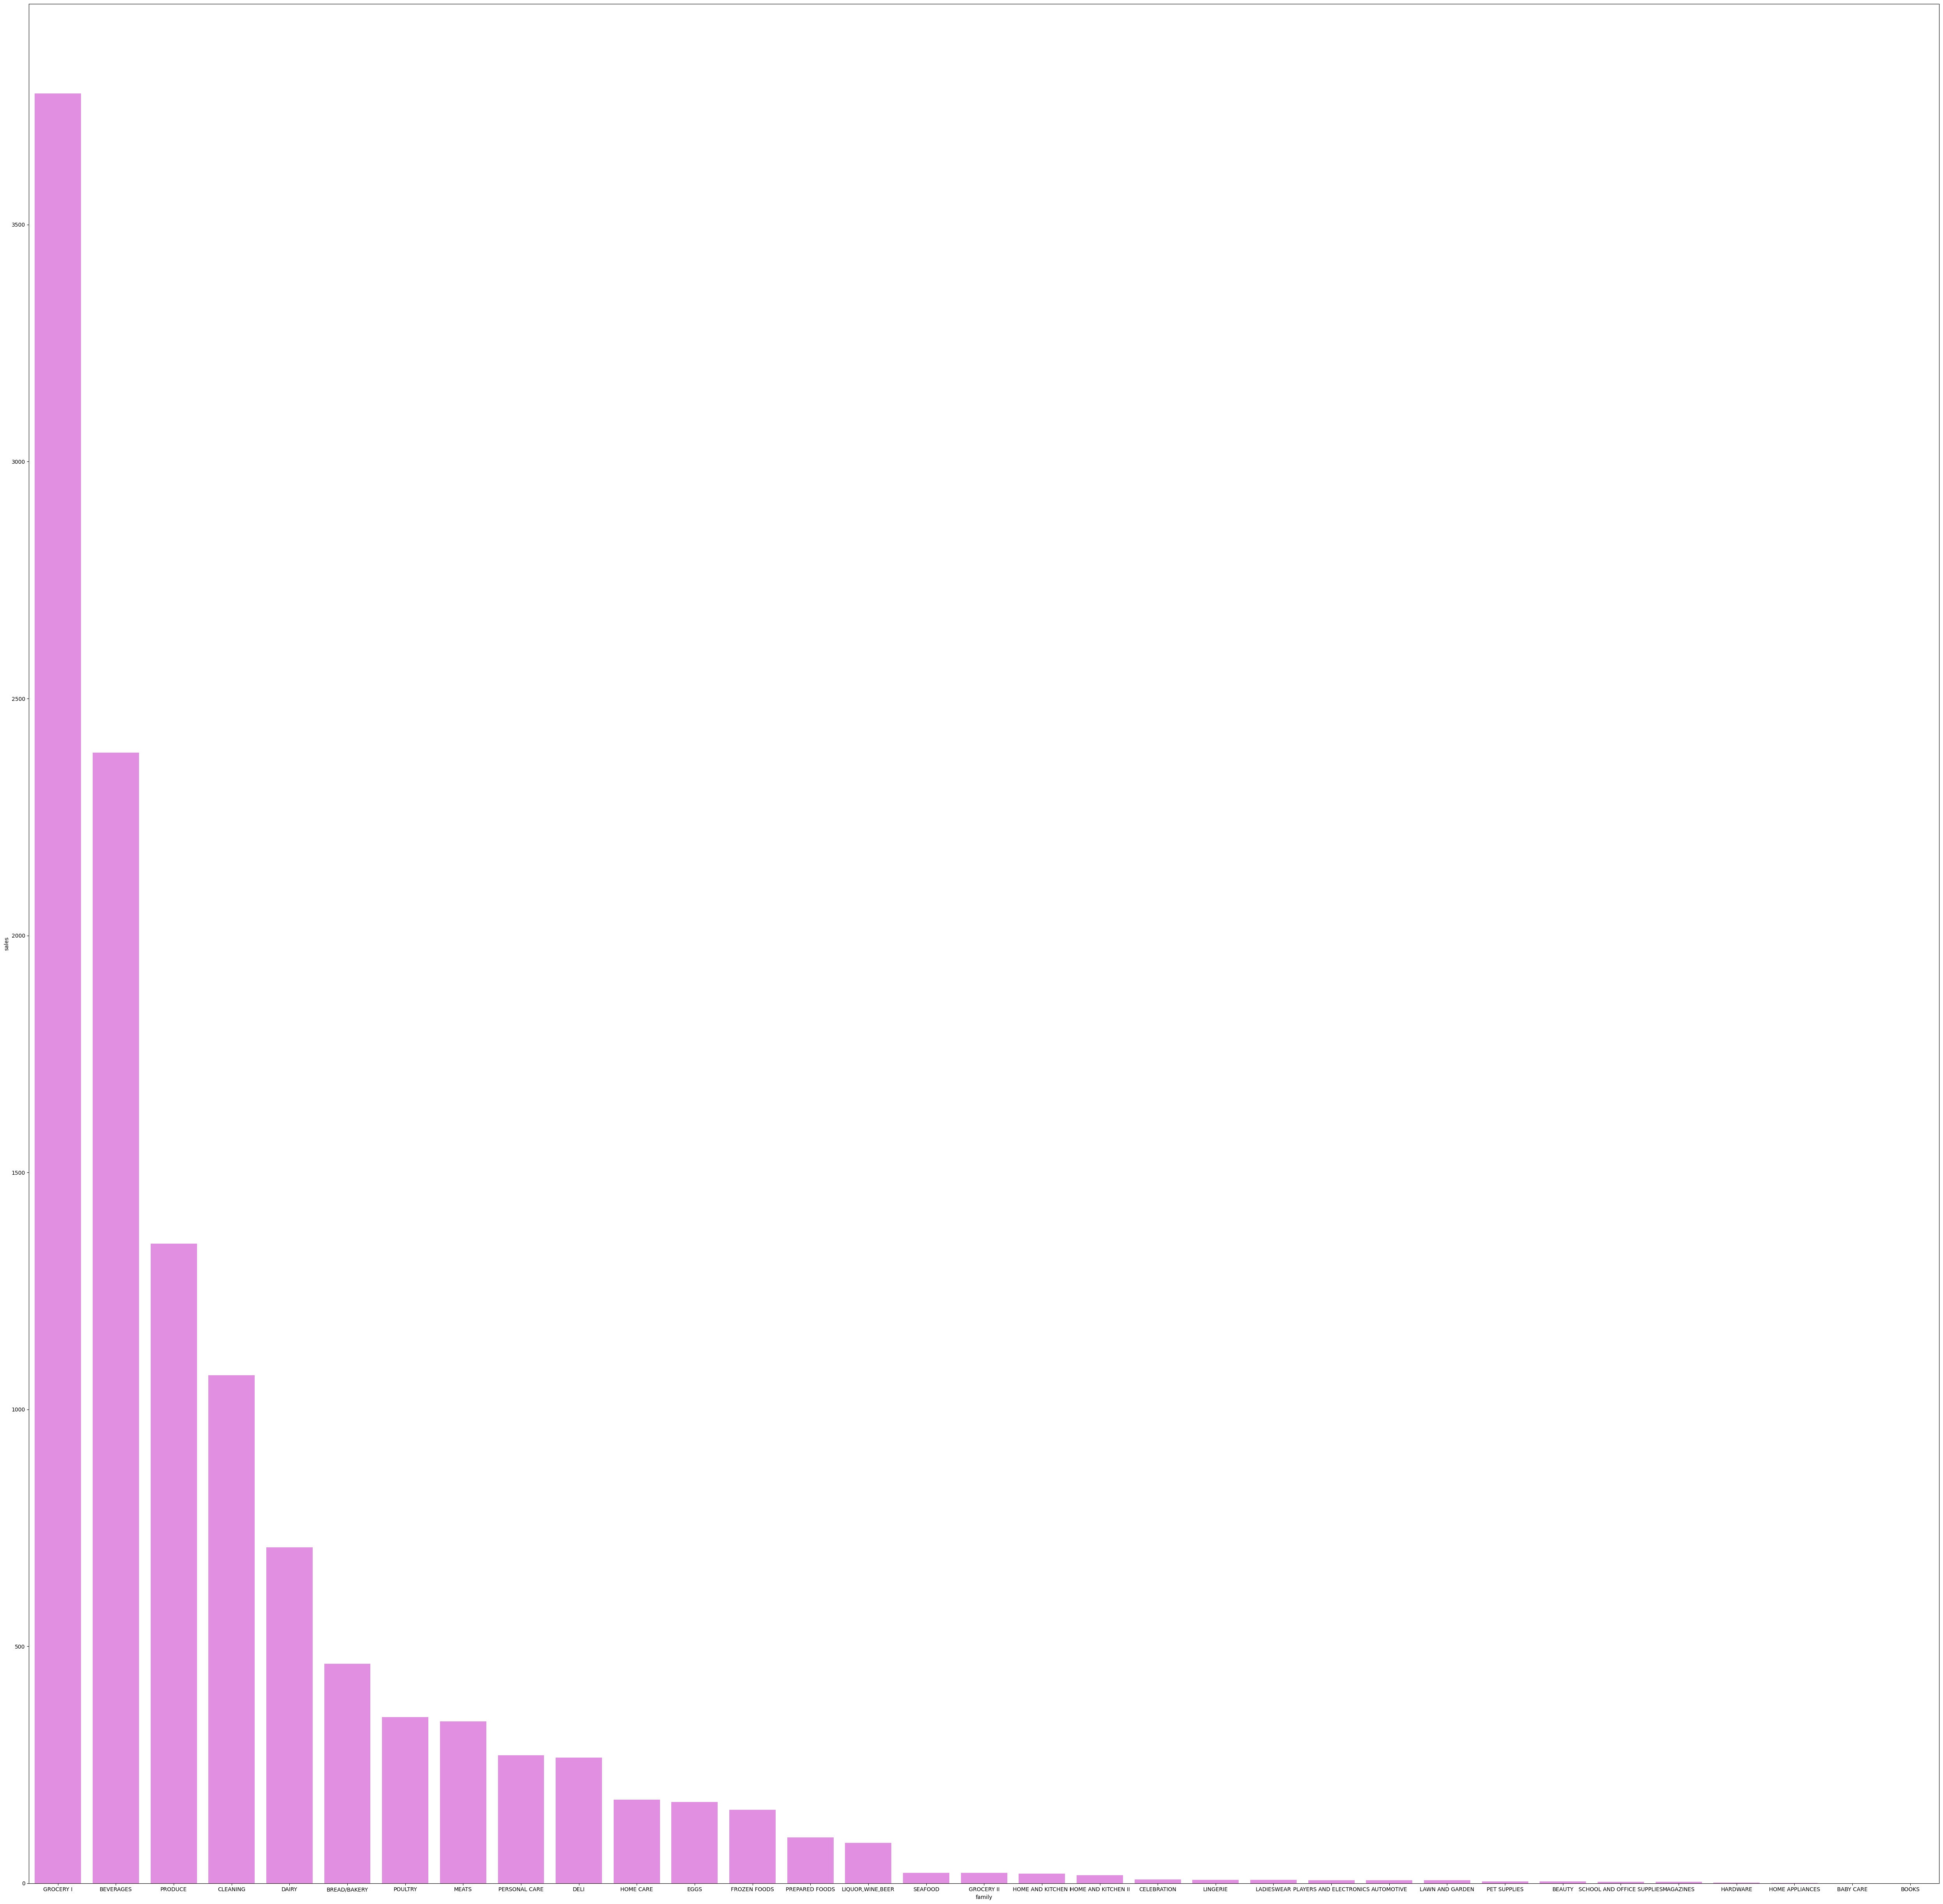

,family,sales
0,GROCERY I,3776.972100
1,BEVERAGES,2385.793151
2,PRODUCE,1349.352123
3,CLEANING,1072.416744
4,DAIRY,709.154889
5,BREAD/BAKERY,463.336254
6,POULTRY,350.532292
7,MEATS,341.849965
8,PERSONAL CARE,270.432513
9,DELI,265.135067


In [15]:
family_sales=df1.groupby(['family'])['sales'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(50,49))
sns.barplot(x='family',y='sales',data=family_sales,color='violet') #avg sales for  each family
plt.tight_layout()
plt.show()
family_sales


<Axes: >

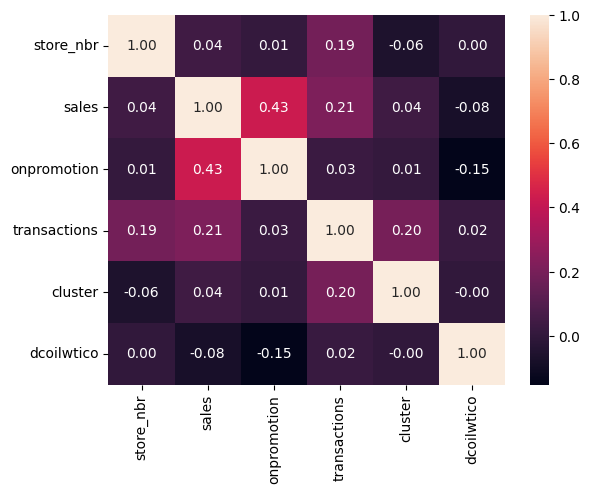

In [36]:
sns.heatmap(df1.select_dtypes(include=['int64','float64']).corr(),annot=True,fmt='.2f')

In [ ]:
national_holiday_sales=df1.groupby(['National_Holiday','Local_Holiday','city'])['sales'].mean().sort_values(ascending=False).reset_index()
national_holiday_sales['city'].unique() #To know on which National Holidays sales are increasing
#'Ambato', 'Libertad', 'Salinas', 'Riobamba', 'Machala', 'Latacunga', 'Puyo'
 #    These are the Cities where NATIONAL HOLIDAY AND LOCAL HOLIDAY ARE CONTRIBUTING MORE TO SALES WHICH ARE ON SAME DATE

array(['Ambato', 'Libertad', 'Salinas', 'Riobamba', 'Machala',
       'Latacunga', 'Puyo'], dtype=object)

In [ ]:
df1.groupby(['state','Regional_Holiday'])['sales'].mean().sort_values(ascending=False).reset_index() #Regional Holidays are not present for many states ,So sales can be incresed from LOCAL HOLIDAYS AND NATIONAL HOLIDAYS


,state,Regional_Holiday,sales
0,Santo Domingo de los Tsachilas,Provincializacion de Santo Domingo,264.017609
1,Cotopaxi,Provincializacion de Cotopaxi,234.051215
2,Santa Elena,Provincializacion Santa Elena,182.504114
3,Imbabura,Provincializacion de Imbabura,176.549758


In [ ]:
df1.groupby(['city','Local_Holiday'])['sales'].mean().sort_values(ascending=False).reset_index()


,city,Local_Holiday,sales
0,Quito,Fundacion de Quito,786.600770
1,Quito,Fundacion de Quito-1,609.518621
2,Cayambe,Cantonizacion de Cayambe,445.602558
3,Loja,Fundacion de Loja,441.522932
4,Ambato,Independencia de Ambato,359.330708
5,Ambato,Fundacion de Ambato,325.854186
6,Esmeraldas,Fundacion de Esmeraldas,313.340643
7,Guayaquil,"Fundacion de Guayaquil-1,Traslado Fundacion de...",303.655909
8,Machala,Fundacion de Machala,288.350188
9,Cuenca,Fundacion de Cuenca,288.061103


In [ ]:
national_holiday_sales=df1.groupby(['National_Holiday','city'])['sales'].mean().sort_values(ascending=False).reset_index()
national_holiday_sales #NATIONAL HOLIDAY INCREASING SALES

,National_Holiday,city,sales
0,Traslado Primer dia del ano,Quito,1324.689581
1,Terremoto Manabi+1,Quito,1233.286544
2,Terremoto Manabi+1,Daule,1215.212818
3,Terremoto Manabi+2,Quito,1186.848767
4,"Dia del Trabajo,Terremoto Manabi+15",Quito,1164.354720
...,...,...,...
1557,Traslado Independencia de Guayaquil,Puyo,0.000000
1558,Recupero puente primer dia del ano,Libertad,0.000000
1559,Recupero puente Navidad,Manta,0.000000
1560,Mundial de futbol Brasil: Ecuador-Francia,Puyo,0.000000


In [ ]:
                                      #Final Observations
# Sales are INCRESING DUE TO NATIONAL HOLIDAY
# sales are INCREASING DUE TO COMBINATION OF NATIONAL HOLIDAY AND LOCAL HOLIDAY OR LOCAL HOLIDAY ALONE
#sales are not THAT MUCH INCREASING DUE TO REGIONAL HOLIDAYS BECAUSE ONLY SOME STATES HAVE REGIONAL HOLIDAYS AND INCRESE IN SALES IS MAINLY
#DUE TO NATIONAL AND LOCAL HOLIDAY IN EACH STATE RESPECTIVELY

In [ ]:
print(df1.groupby(['National_transferred'])['sales'].mean().sort_values(ascending=False))
df1.groupby(['National_Holiday_Type'])['sales'].mean().sort_values(ascending=False)
#Holiday and Event combinely generating more sales

National_transferred
False    419.339289
True     281.197453
Name: sales, dtype: float64


,sales
National_Holiday_Type,
"Holiday,Event",712.750397
"Additional,Event",601.118281
Additional,520.019819
"Bridge,Additional",489.393073
Transfer,474.340800
"Event,Event",460.619887
Bridge,425.429744
Event,415.420292
Work Day,372.157524


In [ ]:
print(df1.groupby(['Local_transferred'])['sales'].mean().sort_values(ascending=False))
df1.groupby(['Local_Holiday_Type'])['sales'].mean().sort_values(ascending=False)
#Additional Hoolidays for Local Festivals increses the SALES

Local_transferred
False    427.115047
True     353.676218
Name: sales, dtype: float64


,sales
Local_Holiday_Type,
Additional,502.783108
Transfer,422.578768
Holiday,397.130580
"Additional,Transfer",303.655909


In [ ]:
df1.isnull().sum()
print(df1.groupby(['Regional_transferred'])['sales'].mean().sort_values(ascending=False))
df1.groupby(['Regional_Holiday_Type'])['sales'].mean().sort_values(ascending=False)

Regional_transferred
False    229.725442
Name: sales, dtype: float64


,sales
Regional_Holiday_Type,
Holiday,229.725442


In [10]:
#fillling null values
import warnings
warnings.filterwarnings('ignore')
df1['National_Holiday']= df1['National_Holiday'].fillna('No_Holiday')
df1['National_Holiday_Type']= df1['National_Holiday_Type'].fillna('No_Holiday')
df1['National_transferred']= df1['National_transferred'].fillna(False)
df1['Regional_Holiday']= df1['Regional_Holiday'].fillna('No_Holiday')
df1['Regional_Holiday_Type']= df1['Regional_Holiday_Type'].fillna('No_Holiday')
df1['Regional_transferred']= df1['Regional_transferred'].fillna(False)
df1['Local_Holiday']= df1['Local_Holiday'].fillna('No_Holiday')
df1['Local_Holiday_Type']= df1['Local_Holiday_Type'].fillna('No_Holiday')
df1['Local_transferred']= df1['Local_transferred'].fillna(False)
df1.isnull().sum()
#For remaining NULL VALUES WE USE SIMPLE IMPUTER
#IF I USE SIMPLE IMPUTER FOR FILLING NULL VALUES FOR NATIONAL ,REGIONAL AND LOCAL IT LEADS TO HAVING SAME FESTIVAL ON DIFFERENT DATES


,0
store_nbr,0
family,0
sales,0
onpromotion,0
transactions,245784
city,0
state,0
type,0
cluster,0
dcoilwtico,928422


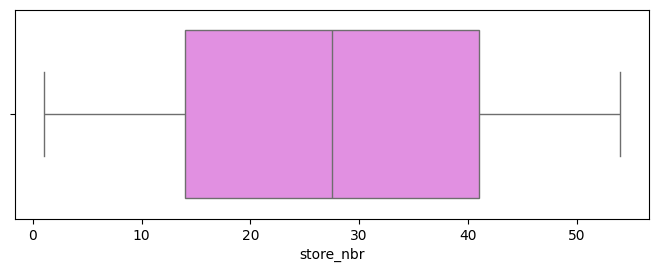

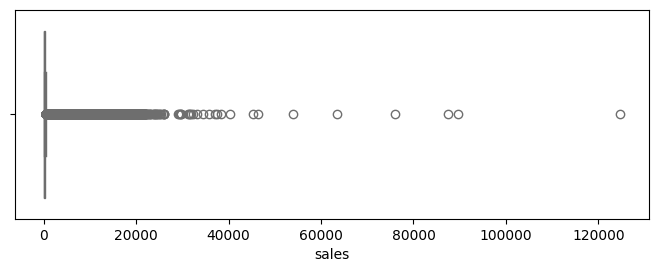

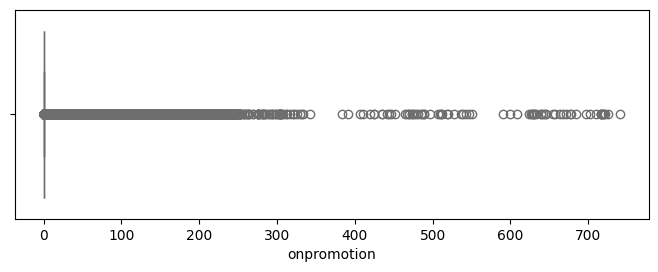

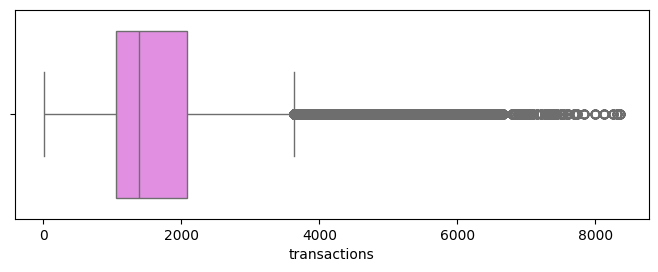

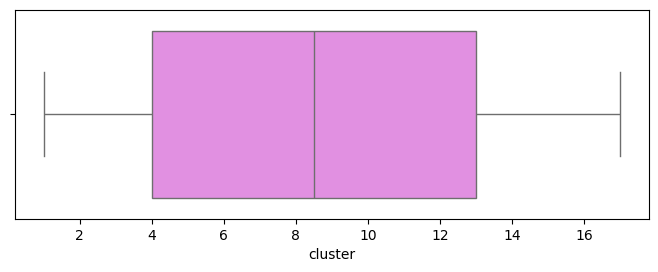

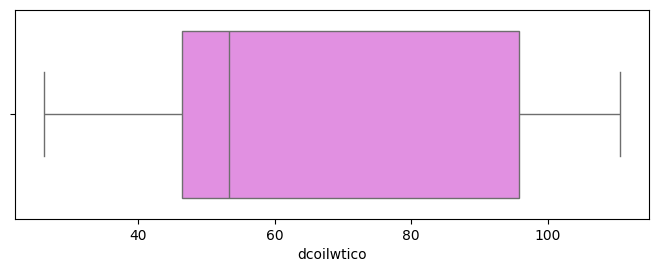

In [ ]:
num = df1.select_dtypes(include=['int64','float64']).columns
for i,col in enumerate(num):
  plt.figure(figsize=(18,19))
  plt.subplot(len(num),2,2*i+1)
  sns.boxplot(x=df1[col],data = df1,color='violet')


In [ ]:
df1.select_dtypes(include=['int64','float64']).skew()
#to apply Power transformer

,0
store_nbr,0.000000
sales,7.358758
onpromotion,11.166562
transactions,1.518325
cluster,0.040087
dcoilwtico,0.303349


In [11]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor
from xgboost import XGBRegressor



In [12]:
df1= df1.drop(['National_Holiday','Regional_Holiday','Local_Holiday'],axis =1)

In [19]:
df1.select_dtypes(include='object').columns

Index(['family', 'city', 'state', 'type', 'National_Holiday_Type',
       'Regional_Holiday_Type', 'Local_Holiday_Type'],
      dtype='object')

In [13]:
y= df1['sales']
x= df1.drop('sales',axis=1)

In [14]:
class outliercapper(BaseEstimator,TransformerMixin):
  def fit(self,x,y=None):
    q1 = np.percentile(x,25,axis=0)
    q3 = np.percentile(x,75,axis=0)
    self.lower = q1-1.5*(q3-q1)
    self.upper = q3+1.5*(q3-q1)
    return self
  def transform(self,x):
    x = np.clip(x,self.lower,self.upper)
    return x
  def get_feature_names_out(self,input_features=None):
    return input_features

num_pipe =  Pipeline([('impute',SimpleImputer()),('outlier',outliercapper()),('power',PowerTransformer()),('scale',StandardScaler())])
ohe_pipe = Pipeline([('Ohe',OneHotEncoder(handle_unknown='ignore'))])
preprocessor= ColumnTransformer([('num',num_pipe,['onpromotion','transactions','dcoilwtico']),
                                 ('ohe_p',ohe_pipe,df1.select_dtypes(include='object').columns.tolist())],remainder='passthrough')



In [ ]:
main_pipe= Pipeline([('preprocessor',preprocessor),('model',XGBRegressor())])
main_pipe.fit(x,y)
np.mean(cross_val_score(main_pipe,x,y,cv=3,scoring='r2'))

np.float64(0.7930020815644235)

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=42)
main_pipe_1= Pipeline([('preprocessor',preprocessor),('model',XGBRegressor())])
main_pipe_1.fit(x_train,y_train)
y_pred_1= main_pipe_1.predict(x_test)
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error
print('r2_score:',r2_score(y_test,y_pred_1))
print('rmse:',root_mean_squared_error(y_test,y_pred_1))

r2_score: 0.8676207403041698
rmse: 405.61374737370517


In [16]:
#Feature Importance
preprocessor=  main_pipe_1.named_steps['preprocessor']
feature_names=preprocessor.get_feature_names_out()
feature_names= [name.split('__')[-1] for name in feature_names]
xgb= main_pipe_1.named_steps['model']
importance= pd.DataFrame({'feature_names':feature_names,'importance':xgb.feature_importances_})
importance['importance'].sort_values(ascending=False)

,importance
15,0.377859
6,0.135030
10,0.068486
1,0.043726
33,0.042887
...,...
91,0.000000
93,0.000000
96,0.000000
100,0.000000


In [17]:
importance= importance.sort_values(by='importance',ascending = False)
importance.iloc[0:30,:]

,feature_names,importance
15,family_GROCERY I,0.377859
6,family_BEVERAGES,0.135030
10,family_CLEANING,0.068486
1,transactions,0.043726
33,family_PRODUCE,0.042887
11,family_DAIRY,0.031143
31,family_POULTRY,0.029142
27,family_MEATS,0.026033
8,family_BREAD/BAKERY,0.020288
76,type_C,0.019494


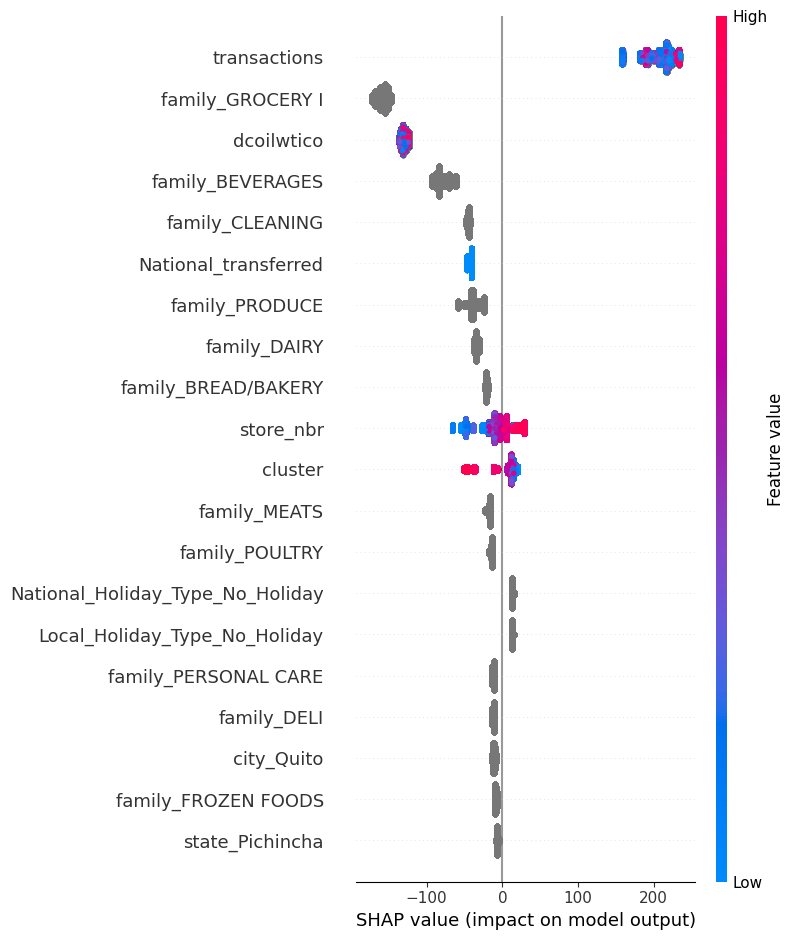

In [18]:
import shap
preprocessor = main_pipe_1.named_steps['preprocessor']
x_test_sample= x_test.sample(n=50,random_state=42)
x_test_trans = preprocessor.transform(x_test_sample)
x_test_trans= pd.DataFrame(x_test,columns=feature_names)
explainer=  shap.TreeExplainer(xgb)
shap_values= explainer.shap_values(x_test_trans)
shap.summary_plot(shap_values,x_test_trans,feature_names=feature_names)

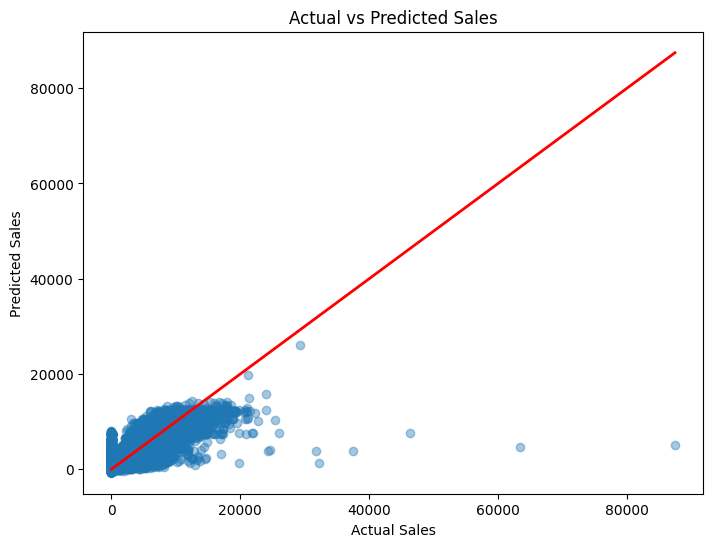

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_1, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()


In [ ]:
#The Actual vs Predicted plot shows that the model predicts most low- and medium-sales observations accurately, as many points lie close to the ideal prediction line.
#However, for a small number of observations with extremely high sales, the model tends to underestimate the actual values.
#This suggests that while the model generalizes well overall, it has difficulty capturing rare peak-sales events.

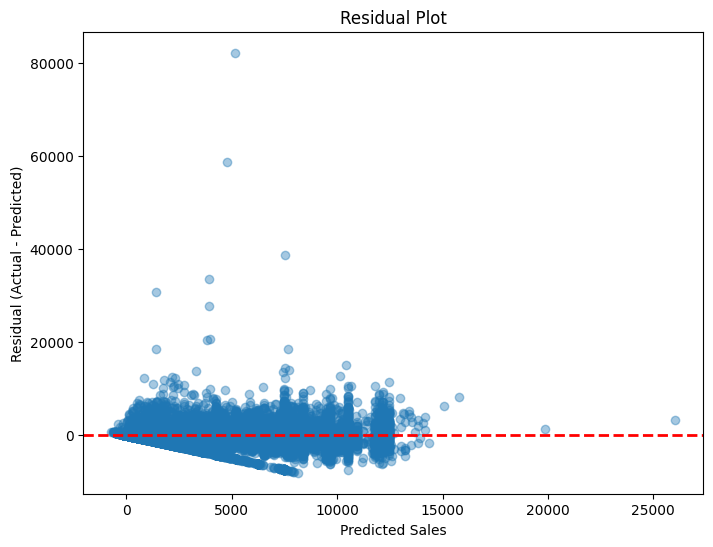

In [20]:
residual = y_test-y_pred_1

plt.figure(figsize=(8,6))

plt.scatter(y_pred_1, residual, alpha=0.4)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [ ]:
#The residual plot shows that most residuals are centered around zero, indicating that the model predicts the majority of observations accurately.
#However, a few observations exhibit very large positive residuals, suggesting that the model underestimates rare high-sales events.
#This behavior is consistent with the Actual vs Predicted plot and indicates that while the model performs well overall, predicting extreme peak sales remains challenging.